# 19 — Hyperbolic entropy: build e−, compute H_𝔻 (5,000-user cohort)

Supports the paper draft (`docs/paper_latent_feature_discovery_draft.md`), §3.1–3.2 and the §4.4 entropy-gap analysis.

- **eₘ (real part)**: the already-trained Real RBM (`channelB1_softmax`, `W1`/`bh1`) — no retrain.
- **e− (this notebook builds it)**: per-rating deviation from the user's own train-mean, one-hot encoded into K=10 bins — same shape/masking/CD-1 procedure as eₘ, so the two channels are structurally symmetric and comparable. This is a **different construction** from the leniency/extremity/PC1 channels in notebooks 17/18 (those broadcast a single scalar per user across all their movies; this varies per rating).

Design decisions made explicit (confirm/redirect before trusting downstream results):
1. e− is one-hot over K=10 deviation bins, not a continuous scalar — required for `H_𝔻`'s Shannon-entropy definition (§2.3) to apply to each channel.
2. Bin edges are data-driven: 10 equal-width bins spanning the observed train-deviation range, symmetric around 0.
3. User means computed from the **train partition only** (`mask==1`), consistent with the rest of the project.
4. Architecture mirrors eₘ (channel B1) exactly: 128 hidden units, masked CD-1, K=10, `LR=0.01, BATCH_SIZE=500, EPOCHS=50, INIT_SEED=42`.

## Part 0 — Setup

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_dir = root / "data"
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0], dtype=np.float64)
K = len(RATING_LEVELS)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


paths = {
    "W1": proc / "rbmB1_weights_5k.npy",
    "bh1": proc / "rbmB1_bias_hidden_5k.npy",
    "channelB1": proc / "channelB1_softmax.npy",
    "mask": proc / "mask.npy",
    "cohort": proc / "cohort_user_ids.npy",
    "vocab": proc / "movie_vocab.npy",
}
for name, p in paths.items():
    assert p.exists(), f"Missing {p} ({name})"

W1 = np.load(paths["W1"])  # e_+ weights, frozen, reused
bh1 = np.load(paths["bh1"])
channelB1 = np.load(paths["channelB1"], mmap_mode="r")
mask = np.load(paths["mask"], mmap_mode="r")
cohort_user_ids = np.load(paths["cohort"]).astype(int)
movie_vocab = np.load(paths["vocab"]).astype(int)

n_users, n_movies, k_b1 = channelB1.shape
n_hidden = bh1.shape[0]
assert k_b1 == K

user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}
movie_to_col = {int(mid): j for j, mid in enumerate(movie_vocab)}

print(f"Project root: {root}")
print(f"n_users={n_users:,}  n_movies={n_movies:,}  n_hidden={n_hidden}")
print(f"e_+ (real part): W1 {W1.shape}  bh1 {bh1.shape}  (frozen, reused)")

Project root: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys
n_users=5,000  n_movies=13,129  n_hidden=128
e_+ (real part): W1 (131290, 128)  bh1 (128,)  (frozen, reused)


## Part 1 — Build e− (deviation channel)

Decode train ratings from `channelB1` + `mask` (already exactly the train split, per 09b). Compute each user's train-only mean, subtract to get per-rating deviation, bin into K=10 symmetric bins from the empirical range, one-hot encode into the same `(n_users, n_movies, K)` shape as `channelB1_softmax` so e− is structurally identical to e₊.

In [2]:
_t0 = time.time()

# Decode train-only ratings from channelB1 + mask (same pattern as notebooks 17/18)
train_rows = []
step = 250
for i0 in range(0, n_users, step):
    i1 = min(i0 + step, n_users)
    m_block = np.asarray(mask[i0:i1])
    c_block = np.asarray(channelB1[i0:i1])
    for ii in range(i1 - i0):
        cols = np.where(m_block[ii] == 1)[0]
        if len(cols) == 0:
            continue
        ks = c_block[ii, cols, :].argmax(axis=1)
        ratings = RATING_LEVELS[ks]
        uid = int(cohort_user_ids[i0 + ii])
        mids = movie_vocab[cols]
        for mid, r in zip(mids, ratings):
            train_rows.append((uid, int(mid), float(r)))
train_df = pd.DataFrame(train_rows, columns=["userId", "movieId", "rating"])
assert len(train_df) == int(np.asarray(mask).sum())
print(f"Decoded {len(train_df):,} train ratings in {time.time()-_t0:.1f}s")

# Per-user train-only mean
user_mean_df = train_df.groupby("userId")["rating"].mean().rename("user_mean").reset_index()
train_df = train_df.merge(user_mean_df, on="userId", how="left")
train_df["deviation"] = train_df["rating"] - train_df["user_mean"]
print(f"deviation: min={train_df['deviation'].min():.3f} max={train_df['deviation'].max():.3f} "
      f"mean={train_df['deviation'].mean():.4f} std={train_df['deviation'].std():.3f}")

# Symmetric, data-driven bin edges: K=10 equal-width bins spanning [-max|dev|, +max|dev|]
max_abs_dev = float(train_df["deviation"].abs().max())
bin_edges = np.linspace(-max_abs_dev, max_abs_dev, K + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
print(f"bin_edges (K={K}): {np.round(bin_edges, 3)}")

train_df["bin_idx"] = np.clip(np.digitize(train_df["deviation"].to_numpy(), bin_edges[1:-1]), 0, K - 1)
print("bin occupancy:", train_df["bin_idx"].value_counts().sort_index().to_dict())

# One-hot encode into (n_users, n_movies, K), zero elsewhere -- same shape as channelB1_softmax
channelDminus = np.zeros((n_users, n_movies, K), dtype=np.float32)
urow = train_df["userId"].map(user_to_row).to_numpy()
mcol = train_df["movieId"].map(movie_to_col).to_numpy()
bidx = train_df["bin_idx"].to_numpy()
channelDminus[urow, mcol, bidx] = 1.0

np.save(proc / "channelDminus_5k.npy", channelDminus)
np.save(proc / "deviation_bin_edges_5k.npy", bin_edges)
print(f"\nSaved channelDminus_5k.npy {channelDminus.shape} ({channelDminus.nbytes/1e9:.2f} GB)")
print(f"Part 1 done in {time.time()-_t0:.1f}s")

Decoded 4,119,189 train ratings in 10.9s


deviation: min=-3.956 max=3.769 mean=-0.0000 std=0.955
bin_edges (K=10): [-3.956 -3.165 -2.374 -1.582 -0.791  0.     0.791  1.582  2.374  3.165
  3.956]
bin occupancy: {0: 3629, 1: 62258, 2: 204504, 3: 489534, 4: 1153581, 5: 1408277, 6: 649092, 7: 141036, 8: 6803, 9: 475}



Saved channelDminus_5k.npy (5000, 13129, 10) (2.63 GB)
Part 1 done in 25.8s


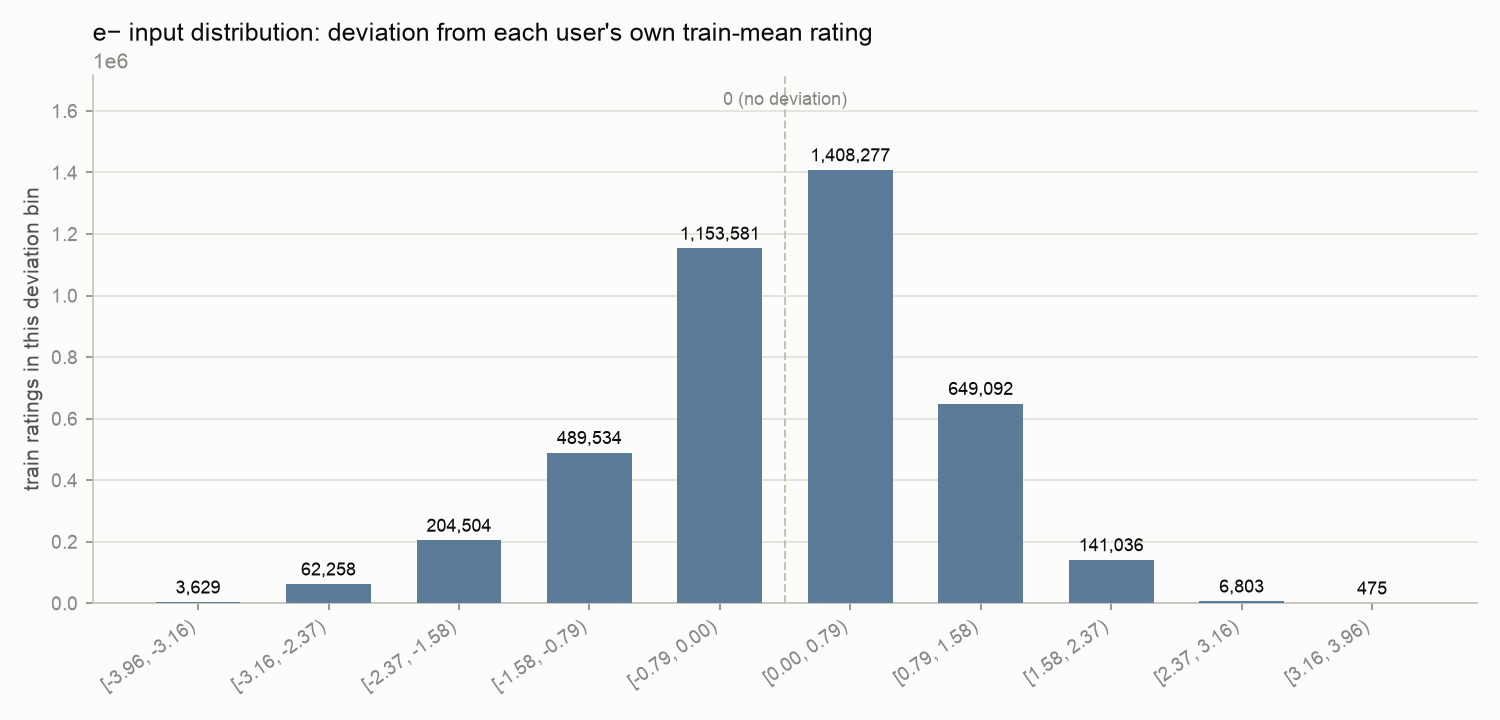

In [1]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BAR_COLOR = "#5b7c99"  # muted dusty blue, matches notebook 18's palette
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

bin_counts = train_df["bin_idx"].value_counts().sort_index()
bin_labels = [f"[{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f})" for i in range(K)]
counts_arr = bin_counts.reindex(range(K), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4.8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(range(K), counts_arr, color=BAR_COLOR, width=0.65, zorder=3)
for i, v in enumerate(counts_arr):
    ax.text(i, v + max(counts_arr) * 0.02, f"{v:,}", ha="center", fontsize=8.5, color=INK_PRIMARY)

ax.set_xticks(range(K))
ax.set_xticklabels(bin_labels, rotation=35, ha="right", fontsize=8.5, color=INK_SECONDARY)
ax.set_ylabel("train ratings in this deviation bin", color=INK_SECONDARY, fontsize=10)
ax.set_title("e− input distribution: deviation from each user's own train-mean rating",
             color=INK_PRIMARY, fontsize=12, loc="left")
ax.axvline(K / 2 - 0.5, color=BASELINE, linewidth=1, linestyle="--", zorder=2)
ax.set_ylim(0, max(counts_arr) * 1.22)
ax.text(K / 2 - 0.5, max(counts_arr) * 1.15, "0 (no deviation)", ha="center", fontsize=8.5, color=INK_MUTED)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / "eminus_deviation_bin_distribution_5k.png", dpi=150, facecolor=SURFACE)
plt.show()

## Part 2 — Train e− (mirrors e₊'s exact architecture)

Same masked CD-1 procedure, same hyperparameters as the real channel's training in `13b_encodingB_personality_training.ipynb`: `N_HIDDEN=128, LR=0.01, BATCH_SIZE=500, EPOCHS=50, INIT_SEED=42`, K=10 one-hot with the movie-level mask expanded ×K per batch. Only the visible-layer content differs (deviation bins instead of rating bins) — e₊ and e₋ are architecturally identical.

In [3]:
N_HIDDEN, LR, BATCH_SIZE, EPOCHS, INIT_SEED = 128, 0.01, 500, 50, 42


def expand_mask_batch(m_movies, k):
    return np.repeat(m_movies, k, axis=1)


def reconstruction_mse(X, M_movies, W, b_h, k_expand, chunk=250):
    n = X.shape[0]
    num, den = 0.0, 0.0
    for i0 in range(0, n, chunk):
        i1 = min(i0 + chunk, n)
        x = np.asarray(X[i0:i1])
        m = M_movies[i0:i1]
        if k_expand > 1:
            m = expand_mask_batch(m, k_expand)
        m = np.asarray(m, dtype=x.dtype)
        h_prob = sigmoid(x @ W + b_h)
        v_prob = sigmoid(h_prob @ W.T)
        num += float(((x - v_prob) ** 2 * m).sum())
        den += float(m.sum())
    return num / den if den > 0 else float("nan")


def train_rbm(X, M_movies, n_hidden, seed, channel_name, k_expand=1):
    rng = np.random.default_rng(seed)
    n_samples, n_visible = X.shape
    W = rng.normal(0.0, 0.01, size=(n_visible, n_hidden)).astype(np.float64)
    b_h = np.zeros(n_hidden, dtype=np.float64)
    print(f"\n=== Training {channel_name} ===  samples={n_samples}, visible={n_visible}, hidden={n_hidden}")
    print(f"  lr={LR}, batch={BATCH_SIZE}, epochs={EPOCHS}, seed={seed}, k_expand={k_expand}", flush=True)
    t0_all = time.time()

    for epoch in range(EPOCHS):
        t0 = time.time()
        epoch_delta = np.zeros_like(W)
        order = rng.permutation(n_samples)
        for start in range(0, n_samples, BATCH_SIZE):
            idx = order[start:start + BATCH_SIZE]
            v_data = np.asarray(X[idx])
            m_batch = M_movies[idx]
            if k_expand > 1:
                m_batch = expand_mask_batch(m_batch, k_expand)
            m_batch = np.asarray(m_batch, dtype=X.dtype)
            bs = v_data.shape[0]

            h_prob = sigmoid(v_data @ W + b_h)
            h_data = (rng.random(h_prob.shape) < h_prob).astype(np.float64)
            v_recon_prob = sigmoid(h_data @ W.T) * m_batch
            v_recon = (rng.random(v_recon_prob.shape) < v_recon_prob).astype(np.float64) * m_batch
            h_recon_prob = sigmoid(v_recon @ W + b_h)
            h_recon = (rng.random(h_recon_prob.shape) < h_recon_prob).astype(np.float64)

            pos = v_data.T @ h_data
            neg = v_recon.T @ h_recon
            epoch_delta += LR * (pos - neg) / bs
            b_h += LR * (h_prob.mean(axis=0) - h_recon_prob.mean(axis=0))

        W += epoch_delta
        dt = time.time() - t0
        ep = epoch + 1
        if ep in (1, 25, EPOCHS):
            mse = reconstruction_mse(X, M_movies, W, b_h, k_expand)
            print(f"  Epoch {ep:02d} | masked recon MSE: {mse:.6f} | wall {dt:.1f}s", flush=True)
        else:
            print(f"  Epoch {ep:02d} | wall {dt:.1f}s", flush=True)
        if ep == 1:
            print(f"  est. full {EPOCHS} epochs ~= {dt * EPOCHS / 60:.1f} min", flush=True)

    print(f"  Done in {(time.time()-t0_all)/60:.1f} min")
    return W, b_h


print("Loading channelDminus into X_minus ...")
channelDminus_mm = np.load(proc / "channelDminus_5k.npy")
X_minus = channelDminus_mm.reshape(n_users, -1)
del channelDminus_mm
M2 = np.asarray(mask).astype(np.float32)

W_minus, bh_minus = train_rbm(X_minus, M2, N_HIDDEN, INIT_SEED, "e_minus (deviation)", k_expand=K)

np.save(proc / "rbmDminus_weights_5k.npy", W_minus)
np.save(proc / "rbmDminus_bias_hidden_5k.npy", bh_minus)
print(f"\nSaved rbmDminus_weights_5k.npy {W_minus.shape}, rbmDminus_bias_hidden_5k.npy {bh_minus.shape}")

Loading channelDminus into X_minus ...



=== Training e_minus (deviation) ===  samples=5000, visible=131290, hidden=128
  lr=0.01, batch=500, epochs=50, seed=42, k_expand=10


  Epoch 01 | masked recon MSE: 0.240118 | wall 28.2s


  est. full 50 epochs ~= 23.5 min


  Epoch 02 | wall 25.9s


...

  Epoch 48 | wall 32.0s


  Epoch 49 | wall 32.8s


  Epoch 50 | masked recon MSE: 0.117751 | wall 32.4s


  Done in 23.0 min



Saved rbmDminus_weights_5k.npy (131290, 128), rbmDminus_bias_hidden_5k.npy (128,)
